In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all four datasets
plant1_generation = pd.read_csv("data/Plant_1_Generation_Data.csv")
plant1_weather = pd.read_csv("data/Plant_1_Weather_Sensor_Data.csv")

plant2_generation = pd.read_csv("data/Plant_2_Generation_Data.csv")
plant2_weather = pd.read_csv("data/Plant_2_Weather_Sensor_Data.csv")

# Display dataset information
print("Plant 1 Generation:", plant1_generation.shape)
print("Plant 1 Weather:", plant1_weather.shape)
print("Plant 2 Generation:", plant2_generation.shape)
print("Plant 2 Weather:", plant2_weather.shape)

print("\nPlant 1 Generation Columns:")
print(plant1_generation.columns.tolist())

print("\nPlant 1 Weather Columns:")
print(plant1_weather.columns.tolist())

print("\nPlant 2 Generation Columns:")
print(plant2_generation.columns.tolist())

print("\nPlant 2 Weather Columns:")
print(plant2_weather.columns.tolist())

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)

Plant 1 Generation Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Plant 1 Weather Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

Plant 2 Generation Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Plant 2 Weather Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [3]:
datasets = {
    "Plant 1 Generation": plant1_generation,
    "Plant 1 Weather": plant1_weather,
    "Plant 2 Generation": plant2_generation,
    "Plant 2 Weather": plant2_weather
}

for name, data in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Date range:")
    print(data["DATE_TIME"].min(), "to", data["DATE_TIME"].max())

    print("\nMissing values:")
    print(data.isnull().sum())

    print("\nDuplicate rows:", data.duplicated().sum())


Plant 1 Generation
Date range:
01-06-2020 00:00 to 31-05-2020 23:45

Missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

Duplicate rows: 0

Plant 1 Weather
Date range:
2020-05-15 00:00:00 to 2020-06-17 23:45:00

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Duplicate rows: 0

Plant 2 Generation
Date range:
2020-05-15 00:00:00 to 2020-06-17 23:45:00

Missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

Duplicate rows: 0

Plant 2 Weather
Date range:
2020-05-15 00:00:00 to 2020-06-17 23:45:00

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int

In [4]:
# Convert DATE_TIME into proper datetime format

plant1_generation["DATE_TIME"] = pd.to_datetime(
    plant1_generation["DATE_TIME"],
    dayfirst=True
)

plant1_weather["DATE_TIME"] = pd.to_datetime(
    plant1_weather["DATE_TIME"]
)

plant2_generation["DATE_TIME"] = pd.to_datetime(
    plant2_generation["DATE_TIME"],
    dayfirst=True
)

plant2_weather["DATE_TIME"] = pd.to_datetime(
    plant2_weather["DATE_TIME"]
)

# Check the corrected date ranges
datasets = {
    "Plant 1 Generation": plant1_generation,
    "Plant 1 Weather": plant1_weather,
    "Plant 2 Generation": plant2_generation,
    "Plant 2 Weather": plant2_weather
}

for name, data in datasets.items():
    print(name)
    print("Start:", data["DATE_TIME"].min())
    print("End:  ", data["DATE_TIME"].max())
    print()

Plant 1 Generation
Start: 2020-05-15 00:00:00
End:   2020-06-17 23:45:00

Plant 1 Weather
Start: 2020-05-15 00:00:00
End:   2020-06-17 23:45:00

Plant 2 Generation
Start: 2020-05-15 00:00:00
End:   2020-06-17 23:45:00

Plant 2 Weather
Start: 2020-05-15 00:00:00
End:   2020-06-17 23:45:00



C:\Users\Dell\AppData\Local\Temp\ipykernel_14612\1131243067.py:12: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  plant2_generation["DATE_TIME"] = pd.to_datetime(


In [5]:
# Merge Plant 1 generation and weather data using DATE_TIME

plant1_data = pd.merge(
    plant1_generation,
    plant1_weather,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

print("Plant 1 merged dataset shape:", plant1_data.shape)

print("\nColumns:")
print(plant1_data.columns.tolist())

print("\nFirst 5 rows:")
display(plant1_data.head())

Plant 1 merged dataset shape: (68774, 11)

Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 5 rows:


,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [6]:
# Select useful columns for ML

plant1_data = plant1_data[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY_x",
        "DC_POWER",
        "AC_POWER",
        "DAILY_YIELD",
        "TOTAL_YIELD",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]
]

# Rename inverter source column
plant1_data = plant1_data.rename(
    columns={"SOURCE_KEY_x": "SOURCE_KEY"}
)

print("Plant 1 dataset shape:", plant1_data.shape)

print("\nFinal columns:")
print(plant1_data.columns.tolist())

print("\nMissing values:")
print(plant1_data.isnull().sum())

Plant 1 dataset shape: (68774, 10)

Final columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [7]:
# Select ML features
features = [
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE"
]

X = plant1_data[features]
y = plant1_data["AC_POWER"]

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 feature rows:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

Features:
['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

Feature shape: (68774, 3)
Target shape: (68774,)

First 5 feature rows:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
0,0.0,25.184316,22.857507
1,0.0,25.184316,22.857507
2,0.0,25.184316,22.857507
3,0.0,25.184316,22.857507
4,0.0,25.184316,22.857507



First 5 target values:


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: AC_POWER, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (55019, 3)
Testing features: (13755, 3)
Training target: (55019,)
Testing target: (13755,)


In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

Predictions completed!

First 10 actual values:
[873.2375       0.         613.7857143    0.          98.62857143
 945.0285714  643.3857143  168.7        372.0714286    0.        ]

First 10 predicted values:
[987.95532291   0.         674.67708386   0.          95.15000096
 925.03595514 657.87965133 173.97385508 371.94804254   0.        ]


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
------------------
MAE  : 16.37
RMSE : 45.67
R²   : 0.9865


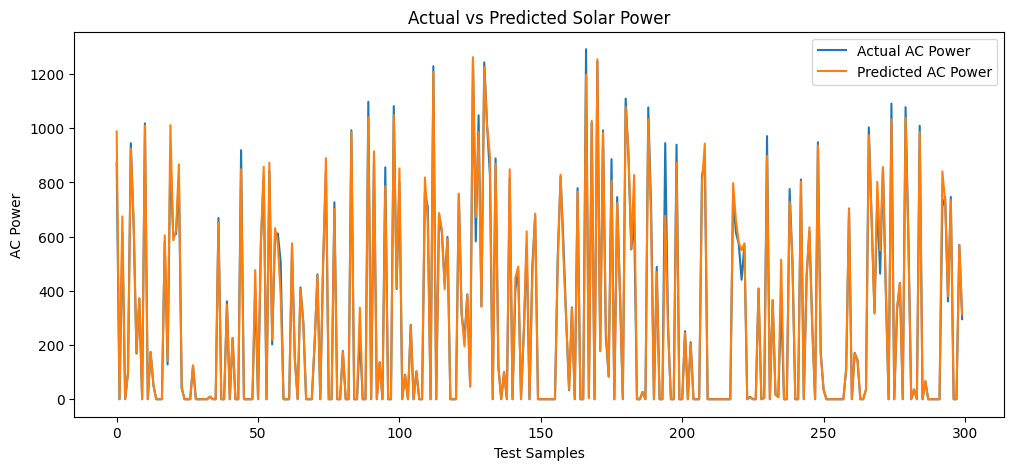

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:300], label="Actual AC Power")
plt.plot(y_pred[:300], label="Predicted AC Power")

plt.title("Actual vs Predicted Solar Power")
plt.xlabel("Test Samples")
plt.ylabel("AC Power")
plt.legend()
plt.show()

In [13]:
# Calculate prediction error

prediction_error = y_test.values - y_pred

print("Prediction error calculated!")

print("\nFirst 10 errors:")
print(prediction_error[:10])

Prediction error calculated!

First 10 errors:
[-114.71782291    0.          -60.89136956    0.            3.47857047
   19.99261626  -14.49393703   -5.27385508    0.12338606    0.        ]


In [14]:
# Calculate anomaly threshold

error_mean = np.mean(prediction_error)
error_std = np.std(prediction_error)

upper_threshold = error_mean + (3 * error_std)
lower_threshold = error_mean - (3 * error_std)

print("Error Mean:", round(error_mean, 2))
print("Error Std:", round(error_std, 2))

print("\nUpper Threshold:", round(upper_threshold, 2))
print("Lower Threshold:", round(lower_threshold, 2))

Error Mean: 0.1
Error Std: 45.67

Upper Threshold: 137.11
Lower Threshold: -136.91


In [15]:
# Detect anomalies

anomalies = (
    (prediction_error > upper_threshold) |
    (prediction_error < lower_threshold)
)

anomaly_count = np.sum(anomalies)
total_samples = len(prediction_error)

print("Anomaly Detection Results")
print("--------------------------")
print("Total test samples:", total_samples)
print("Anomalies detected:", anomaly_count)

print(
    "Anomaly percentage:",
    round((anomaly_count / total_samples) * 100, 2),
    "%"
)

Anomaly Detection Results
--------------------------
Total test samples: 13755
Anomalies detected: 255
Anomaly percentage: 1.85 %


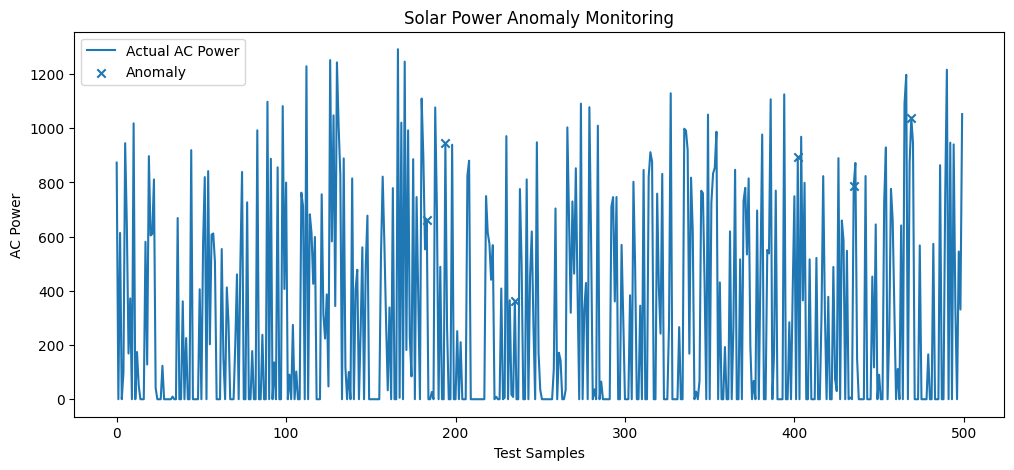

Anomalies shown in first 500 test samples: 6


In [16]:
# Visualize detected anomalies

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual AC Power"
)

anomaly_indices = np.where(anomalies[:500])[0]

plt.scatter(
    anomaly_indices,
    y_test.values[:500][anomaly_indices],
    label="Anomaly",
    marker="x"
)

plt.title("Solar Power Anomaly Monitoring")
plt.xlabel("Test Samples")
plt.ylabel("AC Power")
plt.legend()
plt.show()

print("Anomalies shown in first 500 test samples:", len(anomaly_indices))

In [17]:
import joblib

joblib.dump(model, "solar_power_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [18]:
# Create anomaly monitoring results

results = X_test.copy()

results["Actual_AC_Power"] = y_test.values
results["Predicted_AC_Power"] = y_pred
results["Prediction_Error"] = prediction_error
results["Anomaly"] = anomalies

results.to_csv(
    "solar_power_anomaly_results.csv",
    index=False
)

print("Anomaly results saved successfully!")

print("\nTotal records:", len(results))
print("Anomalies:", results["Anomaly"].sum())

display(results.head())

Anomaly results saved successfully!

Total records: 13755
Anomalies: 255


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,Actual_AC_Power,Predicted_AC_Power,Prediction_Error,Anomaly
48910,0.823869,30.200903,51.813019,873.237500,987.955323,-114.717823,False
45151,0.002115,23.801898,23.067796,0.000000,0.000000,0.000000,False
17954,0.418877,27.404045,41.316923,613.785714,674.677084,-60.891370,False
51959,0.000000,22.775156,20.823775,0.000000,0.000000,0.000000,False
53225,0.063961,26.491622,29.685520,98.628571,95.150001,3.478570,False


In [19]:
# Feature importance

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
0,IRRADIATION,0.996485
2,MODULE_TEMPERATURE,0.002064
1,AMBIENT_TEMPERATURE,0.001451


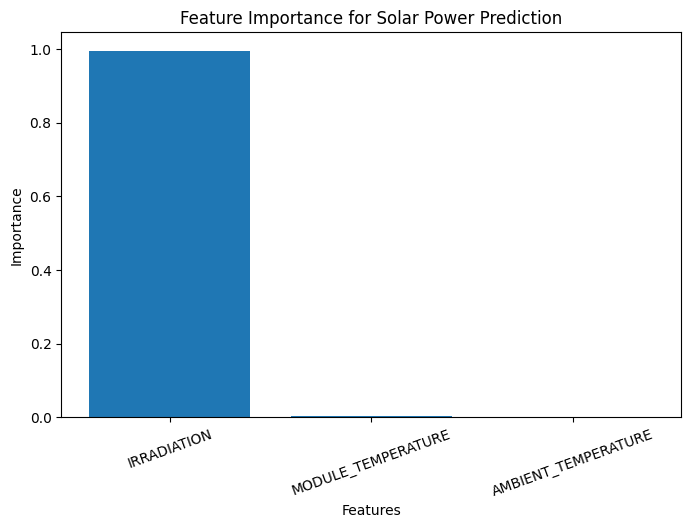

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance for Solar Power Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=20)

plt.show()

In [21]:
# Merge Plant 2 generation and weather data

plant2_data = pd.merge(
    plant2_generation,
    plant2_weather,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

print("Plant 2 merged dataset shape:", plant2_data.shape)

print("\nColumns:")
print(plant2_data.columns.tolist())

print("\nFirst 5 rows:")
display(plant2_data.head())

Plant 2 merged dataset shape: (67698, 11)

Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'SOURCE_KEY_y', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 5 rows:


,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
2,2020-05-15,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
3,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
4,2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0


In [22]:
# Select useful columns for Plant 2

plant2_data = plant2_data[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY_x",
        "DC_POWER",
        "AC_POWER",
        "DAILY_YIELD",
        "TOTAL_YIELD",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]
]

# Rename inverter source column
plant2_data = plant2_data.rename(
    columns={"SOURCE_KEY_x": "SOURCE_KEY"}
)

print("Plant 2 dataset shape:", plant2_data.shape)

print("\nFinal columns:")
print(plant2_data.columns.tolist())

print("\nMissing values:")
print(plant2_data.isnull().sum())

Plant 2 dataset shape: (67698, 10)

Final columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [23]:
# Aggregate Plant 1 inverter data to plant level

plant1_agg = plant1_data.groupby(
    ["DATE_TIME", "PLANT_ID"],
    as_index=False
).agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum",
    "DAILY_YIELD": "sum"
})

print("Plant 1 plant-level shape:", plant1_agg.shape)

display(plant1_agg.head())

Plant 1 plant-level shape: (3157, 5)


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.0
1,2020-05-15 00:15:00,4135001,0.0,0.0,0.0
2,2020-05-15 00:30:00,4135001,0.0,0.0,0.0
3,2020-05-15 00:45:00,4135001,0.0,0.0,0.0
4,2020-05-15 01:00:00,4135001,0.0,0.0,0.0


In [24]:
# Aggregate Plant 2 inverter data to plant level

plant2_agg = plant2_data.groupby(
    ["DATE_TIME", "PLANT_ID"],
    as_index=False
).agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum",
    "DAILY_YIELD": "sum"
})

print("Plant 2 plant-level shape:", plant2_agg.shape)

display(plant2_agg.head())

Plant 2 plant-level shape: (3259, 5)


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD
0,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095
1,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000
2,2020-05-15 00:30:00,4136001,0.0,0.0,28401.000000
3,2020-05-15 00:45:00,4136001,0.0,0.0,28401.000000
4,2020-05-15 01:00:00,4136001,0.0,0.0,26516.000000


In [25]:
# Prepare Plant 1 weather data

plant1_weather_clean = plant1_weather[
    [
        "DATE_TIME",
        "PLANT_ID",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]
]

plant1_final = pd.merge(
    plant1_agg,
    plant1_weather_clean,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

print("Plant 1 final shape:", plant1_final.shape)

print("\nColumns:")
print(plant1_final.columns.tolist())

display(plant1_final.head())

Plant 1 final shape: (3157, 8)

Columns:
['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,0.0,0.0,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,0.0,0.0,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,0.0,0.0,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,0.0,0.0,0.0,24.621525,22.165423,0.0


In [26]:
# Prepare Plant 2 weather data

plant2_weather_clean = plant2_weather[
    [
        "DATE_TIME",
        "PLANT_ID",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]
]

plant2_final = pd.merge(
    plant2_agg,
    plant2_weather_clean,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

print("Plant 2 final shape:", plant2_final.shape)

print("\nColumns:")
print(plant2_final.columns.tolist())

display(plant2_final.head())

Plant 2 final shape: (3259, 8)

Columns:
['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,0.0,0.0,28401.000000,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,0.0,0.0,28401.000000,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,0.0,0.0,26516.000000,26.596148,25.088210,0.0


In [27]:
# Combine Plant 1 and Plant 2

solar_data = pd.concat(
    [plant1_final, plant2_final],
    ignore_index=True
)

# Sort by plant and time
solar_data = solar_data.sort_values(
    ["PLANT_ID", "DATE_TIME"]
).reset_index(drop=True)

print("Combined dataset shape:", solar_data.shape)

print("\nRows by plant:")
print(solar_data["PLANT_ID"].value_counts())

print("\nMissing values:")
print(solar_data.isnull().sum())

display(solar_data.head())

Combined dataset shape: (6416, 8)

Rows by plant:
PLANT_ID
4136001    3259
4135001    3157
Name: count, dtype: int64

Missing values:
DATE_TIME              0
PLANT_ID               0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,0.0,0.0,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,0.0,0.0,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,0.0,0.0,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,0.0,0.0,0.0,24.621525,22.165423,0.0


In [28]:
# Create time-based features

solar_data["HOUR"] = solar_data["DATE_TIME"].dt.hour
solar_data["DAY"] = solar_data["DATE_TIME"].dt.day
solar_data["MONTH"] = solar_data["DATE_TIME"].dt.month
solar_data["DAY_OF_WEEK"] = solar_data["DATE_TIME"].dt.dayofweek

print("Time features created!")

display(
    solar_data[
        [
            "DATE_TIME",
            "HOUR",
            "DAY",
            "MONTH",
            "DAY_OF_WEEK",
            "AC_POWER"
        ]
    ].head()
)

Time features created!


,DATE_TIME,HOUR,DAY,MONTH,DAY_OF_WEEK,AC_POWER
0,2020-05-15 00:00:00,0,15,5,4,0.0
1,2020-05-15 00:15:00,0,15,5,4,0.0
2,2020-05-15 00:30:00,0,15,5,4,0.0
3,2020-05-15 00:45:00,0,15,5,4,0.0
4,2020-05-15 01:00:00,1,15,5,4,0.0


In [29]:
# Prepare final ML features

features = [
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "HOUR",
    "DAY",
    "MONTH",
    "DAY_OF_WEEK",
    "PLANT_ID"
]

X = solar_data[features]
y = solar_data["AC_POWER"]

print("Features:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features:
['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR', 'DAY', 'MONTH', 'DAY_OF_WEEK', 'PLANT_ID']

Feature shape: (6416, 8)
Target shape: (6416,)


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,HOUR,DAY,MONTH,DAY_OF_WEEK,PLANT_ID
0,0.0,25.184316,22.857507,0,15,5,4,4135001
1,0.0,25.084589,22.761668,0,15,5,4,4135001
2,0.0,24.935753,22.592306,0,15,5,4,4135001
3,0.0,24.846130,22.360852,0,15,5,4,4135001
4,0.0,24.621525,22.165423,1,15,5,4,4135001


In [30]:
# Sort data by time

solar_data = solar_data.sort_values("DATE_TIME").reset_index(drop=True)

# Create time-based split

split_index = int(len(solar_data) * 0.8)

X = solar_data[features]
y = solar_data["AC_POWER"]

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(solar_data["DATE_TIME"].iloc[0], "to",
      solar_data["DATE_TIME"].iloc[split_index - 1])

print("\nTesting period:")
print(solar_data["DATE_TIME"].iloc[split_index], "to",
      solar_data["DATE_TIME"].iloc[-1])

Training samples: 5132
Testing samples: 1284

Training period:
2020-05-15 00:00:00 to 2020-06-11 07:00:00

Testing period:
2020-06-11 07:15:00 to 2020-06-17 23:45:00


In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [32]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

Predictions completed!

First 10 actual values:
[2571.3660712  3272.90428571 3155.8571428  3230.22047619 2307.66714286
 4351.6089286  5576.7678571  2230.93714286 6234.8428573  3808.25666667]

First 10 predicted values:
[2369.27228092 3128.68410954 2883.93527145 3156.80218334 2101.76411191
 4104.15409401 5240.99396551 2002.80055952 5682.23364048 3423.60262976]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Solar Power Prediction Performance")
print("------------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Final Solar Power Prediction Performance
------------------------------------------
MAE  : 478.58
RMSE : 1331.62
R²   : 0.9625


In [34]:
# Calculate prediction error

prediction_error = y_test.values - y_pred

print("Prediction error calculated!")

print("\nFirst 10 errors:")
print(prediction_error[:10])

Prediction error calculated!

First 10 errors:
[202.09379028 144.22017617 271.92187135  73.41829285 205.90303095
 247.45483459 335.77389159 228.13658333 552.60921682 384.6540369 ]


In [35]:
# Calculate anomaly threshold

error_mean = np.mean(prediction_error)
error_std = np.std(prediction_error)

upper_threshold = error_mean + (3 * error_std)
lower_threshold = error_mean - (3 * error_std)

print("Final Anomaly Threshold")
print("-----------------------")
print("Error Mean:", round(error_mean, 2))
print("Error Std :", round(error_std, 2))

print("\nUpper Threshold:", round(upper_threshold, 2))
print("Lower Threshold:", round(lower_threshold, 2))

Final Anomaly Threshold
-----------------------
Error Mean: 34.92
Error Std : 1331.16

Upper Threshold: 4028.41
Lower Threshold: -3958.57


In [36]:
# Detect anomalies in the final model

anomalies = (
    (prediction_error > upper_threshold) |
    (prediction_error < lower_threshold)
)

anomaly_count = np.sum(anomalies)
total_samples = len(prediction_error)

print("Final Anomaly Detection Results")
print("--------------------------------")
print("Total test samples:", total_samples)
print("Anomalies detected:", anomaly_count)

print(
    "Anomaly percentage:",
    round((anomaly_count / total_samples) * 100, 2),
    "%"
)

Final Anomaly Detection Results
--------------------------------
Total test samples: 1284
Anomalies detected: 29
Anomaly percentage: 2.26 %


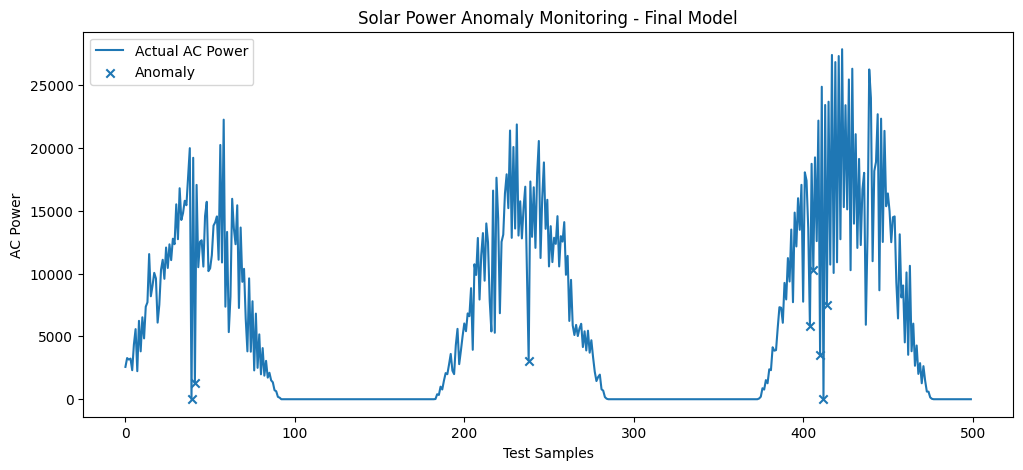

Anomalies shown in first 500 test samples: 8


In [37]:
# Visualize final anomalies

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual AC Power"
)

anomaly_indices = np.where(anomalies[:500])[0]

plt.scatter(
    anomaly_indices,
    y_test.values[:500][anomaly_indices],
    label="Anomaly",
    marker="x"
)

plt.title("Solar Power Anomaly Monitoring - Final Model")
plt.xlabel("Test Samples")
plt.ylabel("AC Power")
plt.legend()

plt.show()

print("Anomalies shown in first 500 test samples:", len(anomaly_indices))

In [38]:
# Save final solar power prediction model

joblib.dump(
    model,
    "solar_power_prediction_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [39]:
# Create final anomaly monitoring results

final_results = solar_data.iloc[
    split_index:
].copy()

final_results["Predicted_AC_Power"] = y_pred
final_results["Prediction_Error"] = prediction_error
final_results["Anomaly"] = anomalies

final_results.to_csv(
    "solar_power_final_anomaly_results.csv",
    index=False
)

print("Final anomaly results saved successfully!")

print("\nTotal test records:", len(final_results))
print("Anomalies detected:", final_results["Anomaly"].sum())

display(
    final_results[
        [
            "DATE_TIME",
            "PLANT_ID",
            "AC_POWER",
            "Predicted_AC_Power",
            "Prediction_Error",
            "Anomaly"
        ]
    ].head()
)

Final anomaly results saved successfully!

Total test records: 1284
Anomalies detected: 29


,DATE_TIME,PLANT_ID,AC_POWER,Predicted_AC_Power,Prediction_Error,Anomaly
5132,2020-06-11 07:15:00,4135001,2571.366071,2369.272281,202.093790,False
5133,2020-06-11 07:15:00,4136001,3272.904286,3128.684110,144.220176,False
5134,2020-06-11 07:30:00,4135001,3155.857143,2883.935271,271.921871,False
5135,2020-06-11 07:30:00,4136001,3230.220476,3156.802183,73.418293,False
5136,2020-06-11 07:45:00,4136001,2307.667143,2101.764112,205.903031,False


In [40]:
# Final feature importance

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Final Feature Importance:")
display(feature_importance)

Final Feature Importance:


,Feature,Importance
0,IRRADIATION,0.927622
7,PLANT_ID,0.043374
4,DAY,0.011935
1,AMBIENT_TEMPERATURE,0.005213
2,MODULE_TEMPERATURE,0.004280
6,DAY_OF_WEEK,0.004146
3,HOUR,0.002371
5,MONTH,0.001060


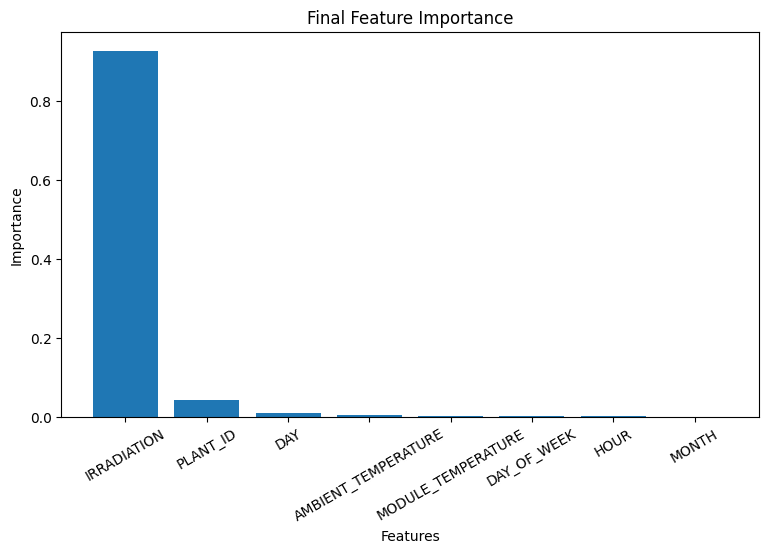

In [41]:
# Visualize final feature importance

plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Final Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=30)

plt.show()